<a href="https://colab.research.google.com/github/pranav-ANIL/DL-and-ML-projects/blob/main/cervical%20cancer/cervical_cancer__pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/cervical_cancer_100k_dataset (1).csv")
df

,Age,Number_of_Sexual_Partners,First_Sexual_Intercourse,Num_of_Pregnancies,Smokes,Smokes_Years,Hormonal_Contraceptives,Hormonal_Contraceptives_Years,STDs,STDs_Number,HPV,Dx_Cancer,Biopsy
0,56,4,20,0,1,3,0,0,0,0,0,0,0
1,59,0,16,4,0,0,0,0,1,5,0,0,0
2,19,2,21,0,1,3,0,0,0,0,0,0,0
3,35,5,20,5,1,12,0,0,0,0,0,1,1
4,41,2,16,3,0,0,0,0,1,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,34,3,15,0,0,0,0,0,0,0,0,0,0
99996,38,2,19,1,1,24,0,0,0,0,0,0,1
99997,63,2,19,0,1,12,0,0,0,0,0,0,0
99998,54,2,16,2,1,9,0,0,0,0,0,0,0


In [ ]:
df.isnull().sum()

,0
Age,0
Number_of_Sexual_Partners,0
First_Sexual_Intercourse,0
Num_of_Pregnancies,0
Smokes,0
Smokes_Years,0
Hormonal_Contraceptives,0
Hormonal_Contraceptives_Years,0
STDs,0
STDs_Number,0


In [ ]:
df.duplicated().sum()

np.int64(9455)

In [ ]:
df.shape

(100000, 13)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(90545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90545 entries, 0 to 99998
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            90545 non-null  int64
 1   Number_of_Sexual_Partners      90545 non-null  int64
 2   First_Sexual_Intercourse       90545 non-null  int64
 3   Num_of_Pregnancies             90545 non-null  int64
 4   Smokes                         90545 non-null  int64
 5   Smokes_Years                   90545 non-null  int64
 6   Hormonal_Contraceptives        90545 non-null  int64
 7   Hormonal_Contraceptives_Years  90545 non-null  int64
 8   STDs                           90545 non-null  int64
 9   STDs_Number                    90545 non-null  int64
 10  HPV                            90545 non-null  int64
 11  Dx_Cancer                      90545 non-null  int64
 12  Biopsy                         90545 non-null  int64
dtypes: int64(13)
memory u

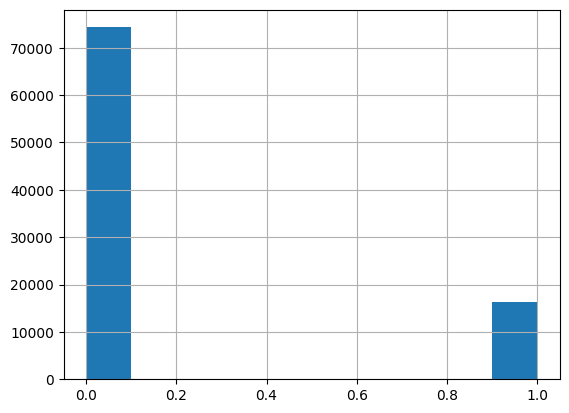

In [ ]:
df["Biopsy"].hist()
plt.show()

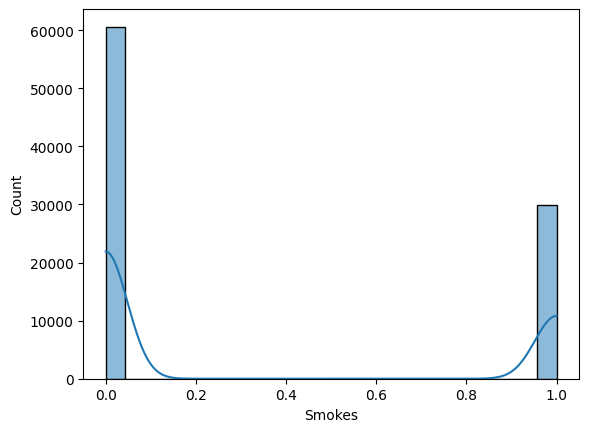

In [ ]:
sns.histplot(df["Smokes"],kde=True)
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import pandas as pd
x = df.drop("Biopsy",axis=1)
y = df["Biopsy"]
for col in x.columns:
    if x[col].dtype == 'object':
        le = LabelEncoder()
        x[col] = le.fit_transform(x[col])
y = LabelEncoder().fit_transform(y)
smote = SMOTE(random_state=42)
x_smote, y_smote = smote.fit_resample(x, y)
df_smote = pd.concat(
    [
        pd.DataFrame(x_smote, columns=x.columns),
        pd.DataFrame(y_smote, columns=["Biopsy"])
    ],
    axis=1)
print(df["Biopsy"].value_counts())
print(df_smote["Biopsy"].value_counts())

print(df_smote.head())

Biopsy
0    74322
1    16223
Name: count, dtype: int64
Biopsy
0    74322
1    74322
Name: count, dtype: int64
   Age  Number_of_Sexual_Partners  First_Sexual_Intercourse  \
0   56                          4                        20   
1   59                          0                        16   
2   19                          2                        21   
3   35                          5                        20   
4   41                          2                        16   

   Num_of_Pregnancies  Smokes  Smokes_Years  Hormonal_Contraceptives  \
0                   0       1             3                        0   
1                   4       0             0                        0   
2                   0       1             3                        0   
3                   5       1            12                        0   
4                   3       0             0                        0   

   Hormonal_Contraceptives_Years  STDs  STDs_Number  HPV  Dx_Cancer  Biopsy  


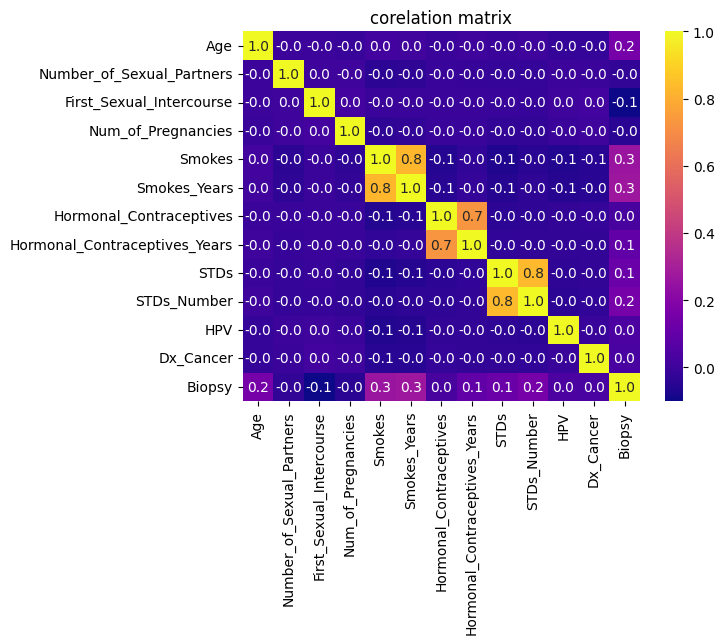

In [ ]:
corr_matrix = df_smote.corr()
sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="plasma")
plt.title("corelation matrix")
plt.show()

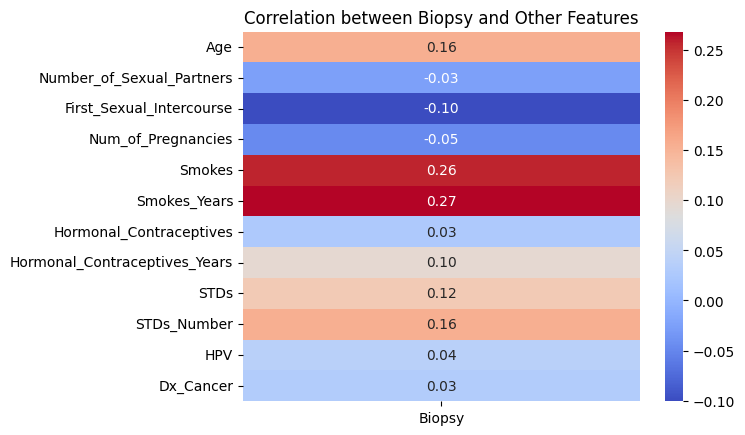

In [ ]:
b_corr = df_smote.corr()['Biopsy']
b_corr = b_corr.drop('Biopsy')
sns.heatmap(b_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Biopsy and Other Features')
plt.show()

In [ ]:
df_smote.drop(["Dx_Cancer","HPV","Hormonal_Contraceptives","Num_of_Pregnancies","Number_of_Sexual_Partners"],axis=1,inplace=True)

<Axes: >

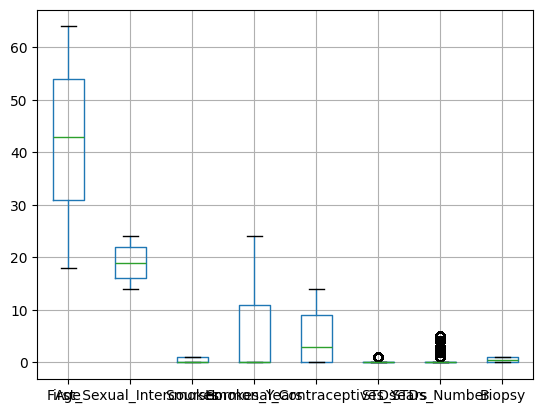

In [ ]:
df_smote.boxplot()

In [ ]:
def remove_outliers_iqr(df_smote, exclude_column):
    for col in df_smote.columns:
        if col == exclude_column:
            continue
        Q1 = df_smote[col].quantile(0.25)
        Q3 = df_smote[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_smote = df_smote[(df_smote[col] >= lower_bound) & (df_smote[col] <= upper_bound)]
    return df_smote


df_cleaned = remove_outliers_iqr(df_smote, exclude_column='Biopsy')
df_smote=df_cleaned

In [ ]:
df

,Age,First_Sexual_Intercourse,Smokes,Smokes_Years,Hormonal_Contraceptives_Years,STDs,STDs_Number,Biopsy
0,56,20,1,3,0,0,0,0
1,59,16,0,0,0,1,5,0
2,19,21,1,3,0,0,0,0
3,35,20,1,12,0,0,0,1
4,41,16,0,0,0,1,3,0
...,...,...,...,...,...,...,...,...
99993,44,17,0,0,0,0,0,0
99994,20,23,0,0,6,0,0,0
99996,38,19,1,24,0,0,0,1
99997,63,19,1,12,0,0,0,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features = ["Age",	"First_Sexual_Intercourse",	"Smokes",	"Smokes_Years",	"Hormonal_Contraceptives_Years",	"STDs",	"STDs_Number"	]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_smote[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
x=df_smote[["Age",	"First_Sexual_Intercourse",	"Smokes",	"Smokes_Years",	"Hormonal_Contraceptives_Years",	"STDs",	"STDs_Number"]]
y=df_smote["Biopsy"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"logistic regression accuracy:{accuracy:.2f}")

logistic regression accuracy:0.66


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pandas as pd

x = df_smote[[
    "Age",
    "First_Sexual_Intercourse",
    "Smokes",
    "Smokes_Years",
    "Hormonal_Contraceptives_Years",
    "STDs",
    "STDs_Number"
]]

y = df_smote["Biopsy"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"RandomForestClassifier Accuracy: {accuracy:.2f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd
x=df_smote[["Age",	"First_Sexual_Intercourse",	"Smokes",	"Smokes_Years",	"Hormonal_Contraceptives_Years",	"STDs",	"STDs_Number"]]
y=df_smote["Biopsy"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=LinearSVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"LinearSVC accuracy:{accuracy:.2f}")

LinearSVC accuracy:0.66


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
x=df_smote[["Age",	"First_Sexual_Intercourse",	"Smokes",	"Smokes_Years",	"Hormonal_Contraceptives_Years",	"STDs",	"STDs_Number"]]
y=df_smote["Biopsy"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"DecisionTreeClassifier accuracy:{accuracy:.2f}")

DecisionTreeClassifier accuracy:0.71


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pandas as pd

x = df_smote[[
    "Age",
    "First_Sexual_Intercourse",
    "Smokes",
    "Smokes_Years",
    "Hormonal_Contraceptives_Years",
    "STDs",
    "STDs_Number"
]]

y = df_smote["Biopsy"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=20,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_alpha=0.2,
    reg_lambda=5,
    eval_metric='logloss',
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"XGBClassifier Accuracy: {accuracy:.2f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

XGBClassifier Accuracy: 0.72

Confusion Matrix
[[11835  3725]
 [ 4285  8949]]

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.76      0.75     15560
           1       0.71      0.68      0.69     13234

    accuracy                           0.72     28794
   macro avg       0.72      0.72      0.72     28794
weighted avg       0.72      0.72      0.72     28794



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
x=df_smote[["Age",	"First_Sexual_Intercourse",	"Smokes",	"Smokes_Years",	"Hormonal_Contraceptives_Years",	"STDs",	"STDs_Number"]]
y=df_smote["Biopsy"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model=AdaBoostClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"AdaBoostClassifier accuracy:{accuracy:.2f}")

AdaBoostClassifier accuracy:0.68


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
x = df_smote.drop("Biopsy",axis=1)
y = df_smote["Biopsy"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
best_accuracy = 0
best_fold = -1
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_x_train = x_train
        best_y_train = y_train
        best_x_test = x_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.663729107879314
Fold 2 Accuracy: 0.6585196440199697
Fold 3 Accuracy: 0.6629911004992403
Fold 4 Accuracy: 0.6619492077273714
Fold 5 Accuracy: 0.6582443344620995

 Best Fold: 1 with Accuracy: 0.663729107879314


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.663729107879314

In [ ]:
model = DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7118732363794226

In [ ]:
model = RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7206859127414803

In [ ]:
model = LinearSVC()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6642934664640764

In [ ]:
model = XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.7025396136314305

In [ ]:
model = AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6799652702409377

# **DL**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
model=Sequential()
model.add(Dense(128,input_dim=7,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [ ]:
model.fit(x_train,y_train,epochs=60,batch_size=42)

Epoch 1/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6714 - loss: 0.6066
Epoch 2/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6724 - loss: 0.6064
Epoch 3/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6726 - loss: 0.6064
Epoch 4/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6712 - loss: 0.6058
Epoch 5/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6727 - loss: 0.6058
Epoch 6/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6732 - loss: 0.6052
Epoch 7/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6734 - loss: 0.6052
Epoch 8/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6730 - loss: 0.6051
Epoch 9/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6739 - loss: 0.6048
Epoch 10/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6738 - loss: 0.6043
Epoch 11/60
2194/2194 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6750 - loss: 0.6045
Epoch 12/60
2194/2194 ━━━━━━

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"model accuracy:{accuracy}")

720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6704 - loss: 0.6040
model accuracy:0.6704002618789673


# **CONCLUSION**
This project focused on predicting cervical cancer using both Machine Learning and Deep Learning techniques. The dataset underwent a complete Exploratory Data Analysis (EDA) process, including data cleaning, handling missing values, feature understanding, visualization, and preprocessing. Since the dataset was imbalanced, the SMOTE (Synthetic Minority Oversampling Technique) method was applied to balance the classes and improve the model’s learning capability.

Several Machine Learning algorithms and a Deep Learning model were implemented and evaluated for prediction performance. Among the Machine Learning models, the Random Forest Classifier achieved the highest accuracy of 72%, making it the best-performing model for this dataset. The Deep Learning model achieved an accuracy of 67%, which was slightly lower compared to the Machine Learning approach.

The results indicate that traditional Machine Learning models, especially Random Forest, performed better than the Deep Learning model for this dataset. This may be due to the relatively smaller dataset size and the structured/tabular nature of the data, where ensemble-based Machine Learning algorithms often perform more effectively than Deep Learning models.

Overall, the project demonstrates that proper preprocessing, imbalance handling using SMOTE, and model comparison are essential steps in building an effective cervical cancer prediction system. The study also highlights the importance of selecting suitable algorithms based on the nature and size of the dataset.